# Week 12 Demo: Estimating Causal Effects Under Interference
## Exposure Mapping for Spillover Effects in Social Network Experiments

### By Farhan Shaikh and Elena Murray

This demo is based on the paper 'Estimating Average Causal Effects Under General Interference, with Application to a Social Network Experiment' by Aronow and Samii (2017). 

## Part 1: Social Network Data

To demonstrate the main concepts from this paper, we will be working with the same data used by Aronow and Samii in Section 10 of the paper: Analysis of a social network experiment. 

This analysis uses data from a real experiment conducted for a previous study by Paluck, Shepard and Aronow (2016). It comes from a field experiment with middle schools in the US, as part of a study on reducing peer conflict and bullying by introducing an intervention called 'Roots' that encouraged students to take a stance against conflcit at school. Students were randomly assigned to the intervention, and surveys were conducted in the same year to capture student's attitudes towards hostile behaviour as well as peers they choose to spend time with to perform social network analysis of all the participating schools.

The data is included in this demo repo, but it is also available here: https://www.pnas.org/doi/10.1073/pnas.1514483113#data-availability 


### Step 1: Load the data and extract the relevant columns. 

In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Load data
df = pd.read_csv(
    "Data/da37070_0001.csv",
    engine="python",
    on_bad_lines="skip"
)

# Replace ICPSR missing codes with NaN
missing_codes = [-55, -66, -77, -88, -95, -96, -97, -98, -99]
df = df.replace(missing_codes, np.nan)

# Select columns
keep_cols = [
    "ID",
    "UID",
    "SCHTREAT",
    "SCHID",
    "TREAT",
    "WRISTW2",
    "ST1","ST2","ST3","ST4","ST5",
    "ST6","ST7","ST8","ST9","ST10"
]
keep_cols = [c for c in keep_cols if c in df.columns]
df_sub = df[keep_cols].copy()

While the original data from the study has data from 56 schools with 24,1919 students, this dataset includes only a sub-set of the data, which we can check with the code below:

In [2]:
#Check the data shape

num_unique_uids = df_sub["UID"].nunique()
print("Number of unique students:", num_unique_uids)

num_unique_schools = df_sub["SCHID"].nunique()
print("Number of unique schools:", num_unique_schools)

Number of unique students: 5989
Number of unique schools: 17


Please note that while this dataset is a subset of the original dataset, the structure and network variables for the schools included are the same. 

### Step 2: Create the Network. 

We build an undirected peer network using the friendship nominations recorded in ST1–ST10. Each student has a unique identifier (UID) and a within-school roster number (ID), and they nominate up to ten friends using these roster numbers, based on the question "Who did you choose to spend time with in the last few weeks". 

Because nominations occur only within the same school (SCHID), we map each (school, roster ID) pair to the corresponding UID. We then create an undirected edge between two students whenever either one nominates the other. The result is a school-clustered undirected graph in which an edge between A and B means that at least one of them named the other as a friend.

In [3]:
def build_directed_adjacency(df_sub, roster_col="ID", school_col="SCHID",
                             st_prefix="ST", st_range=10):
    """
    Build directed adjacency lists from student nomination roster.
    Returns dict: adj[ego_uid] = [list of nominated UIDs]
    """

    df_sub = df_sub.copy()

    # 1. Clean roster ID
    df_sub[roster_col] = (
        df_sub[roster_col].astype(str).str.strip()
        .replace({"--blank--": np.nan, "": np.nan})
    )
    df_sub[roster_col] = pd.to_numeric(df_sub[roster_col], errors="coerce")
    df_sub = df_sub[df_sub[roster_col].notna()].copy()

    # 2. Clean ST nomination columns
    st_cols = [f"{st_prefix}{i}" for i in range(1, st_range + 1)]
    for col in st_cols:
        df_sub[col] = pd.to_numeric(df_sub[col], errors="coerce")

    # 3. Map (school_id, roster_id) → UID
    roster_to_uid = {
        (row.SCHID, row.ID): row.UID
        for row in df_sub.itertuples()
    }

    # 4. Build adjacency
    adj = defaultdict(set)

    for row in df_sub.itertuples():
        ego_uid = row.UID
        school = row.SCHID

        for col in st_cols:
            friend_roster = getattr(row, col)
            if pd.isna(friend_roster):
                continue

            friend_uid = roster_to_uid.get((school, int(friend_roster)))
            if friend_uid is not None:
                adj[ego_uid].add(friend_uid)   # FIXED

    # 5. Convert sets → sorted lists
    adj = {uid: sorted(list(neighs)) for uid, neighs in adj.items()}
    return adj



In [4]:
#Print the first few edges
adjacency_directed= build_directed_adjacency(df_sub)

print("Number of edges:", sum(len(v) for v in adjacency_directed.values()))
list(adjacency_directed.items())[:5]

num_edges = sum(len(v) for v in adjacency_directed.values())
print("Directed edges:", num_edges)
for uid in list(adjacency_directed.keys())[:5]:
    print(uid, "->", adjacency_directed[uid])

Number of edges: 44875
Directed edges: 44875
100001 -> [100002, 100012, 100013, 100022, 100028, 100032, 100077, 100140, 100178, 104999]
100002 -> [100007, 100009, 100013, 100020, 100021, 100031, 100032]
100003 -> [100001, 100014, 100020, 100021, 100024, 100031, 100045, 100072, 100203, 104999]
100004 -> [100002, 100008, 100019, 100022, 100024, 100032, 104999]
100005 -> [100002, 100004, 100010, 100021, 100032, 100045, 100258]


Above, we can see an example of how students have nominated other students who form part of their network. This is easier to see and understand as a visualisation (below). 

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_school_network(df_sub, adj_directed, school_id=None, treat_col="TREAT",
                        figsize=(12, 12), seed=42):
    """
    Visualize the student social network for a single school.

    Parameters
    ----------
    df_sub : DataFrame
        Cleaned dataset containing UID, SCHID, and treatment column.
    adj_directed : dict
        Directed adjacency list: UID -> [list of nominated UIDs]
    school_id : int or None
        School to visualize. If None, the first school is selected.
    treat_col : str
        Column containing treatment codes.
    figsize : tuple
        Figure size for the plot.
    seed : int
        Random seed for layout reproducibility.

    Returns
    -------
    G_lcc : networkx.Graph
        Largest connected component of the school network.
    """

    # 1. Pick school
    if school_id is None:
        school_id = df_sub["SCHID"].unique()[0]

    df_school = df_sub[df_sub["SCHID"] == school_id].copy()
    school_uids = set(df_school["UID"])

    # 2. Extract TREAT_num (0/1)
    df_school["TREAT_num"] = (
        df_school[treat_col]
            .astype(str)
            .str.extract(r"(\d+)")[0]
            .astype(float)
            .fillna(0)
            .astype(int)
    )
    treated_set = set(df_school[df_school["TREAT_num"] == 1]["UID"])

    # 3. Build undirected graph for the school
    G_school = nx.Graph()
    G_school.add_nodes_from(school_uids)

    for ego_uid in school_uids:
        if ego_uid in adj_directed:
            for friend_uid in adj_directed[ego_uid]:
                if friend_uid in school_uids:
                    G_school.add_edge(ego_uid, friend_uid)

    # If no edges exist
    if G_school.number_of_edges() == 0:
        print(f"School {school_id} has no edges to visualize.")
        return None

    # 4. Extract largest connected component
    lcc_nodes = max(nx.connected_components(G_school), key=len)
    G_lcc = G_school.subgraph(lcc_nodes).copy()

    # 5. Node colors
    node_colors = [
        "blue" if uid in treated_set else "white"
        for uid in G_lcc.nodes()
    ]

    # 6. Draw the network
    plt.figure(figsize=figsize)

    pos = nx.spring_layout(G_lcc, seed=seed, k=0.20, iterations=200)

    nx.draw_networkx_edges(
        G_lcc, pos,
        width=0.4, alpha=0.25, edge_color="gray"
    )

    nx.draw_networkx_nodes(
        G_lcc, pos,
        node_size=120,
        node_color=node_colors,
        edgecolors="black",
        linewidths=0.8
    )

    plt.title(
        f"Connected Students Network — School {school_id}\n(Blue = Treated Students)",
        fontsize=15
    )
    plt.axis("off")
    plt.show()

    return G_lcc


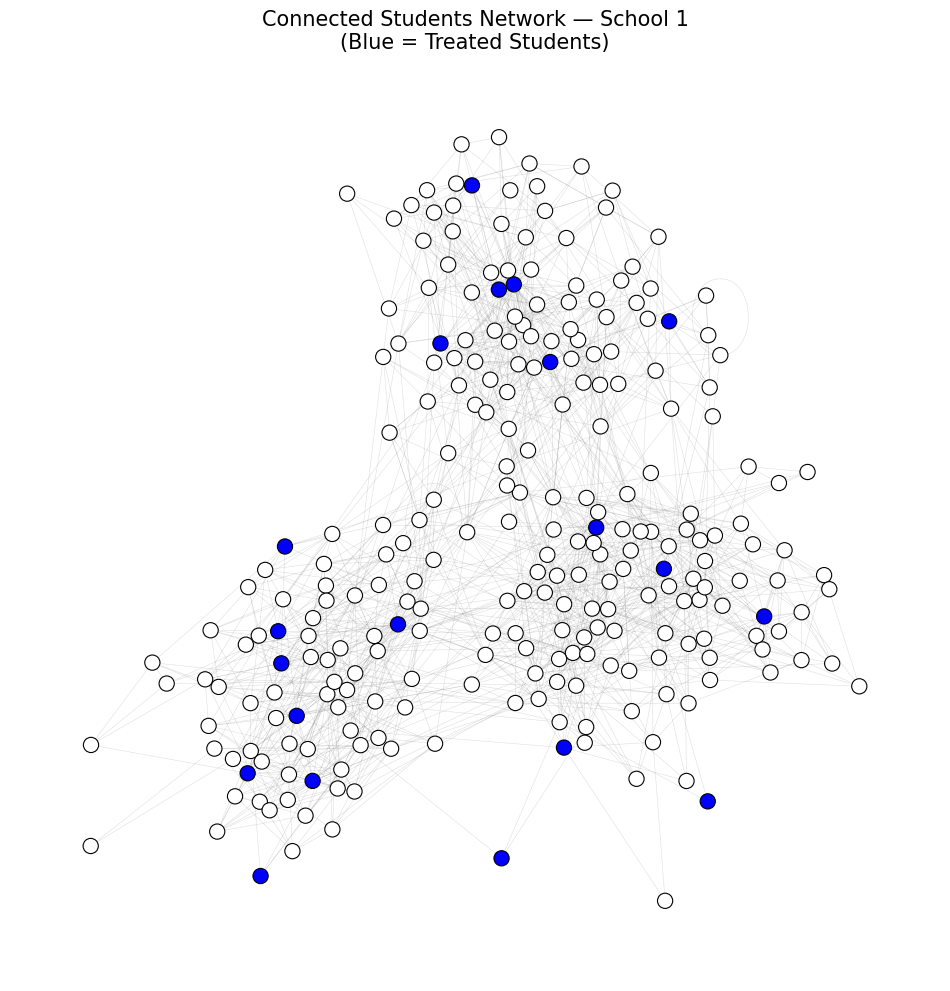

In [10]:
G_school1 = plot_school_network(df_sub, adjacency_directed, school_id=1)

## Part 2: Exposure Mapping

A key concept in Aronow and Saami's paper is the idea of exposure mapping, which relates treatments assigned to exposures received:

$$f(z, \theta_i) \;\in\; \Delta = \{d_1, d_2, \ldots, d_K\}$$

where

- $f(\cdot)$: the exposure mapping
- $\theta_i$: characteristics of unit i (e.g., its neighbors in a network)
- $\Delta$: the set of K possible exposure conditions

This analysis uses the following exposure mappings:

- d000: control school
- d001: treated school but student untreated, no treated neighbours
- d011: student untreated, ≥1 treated neighbour
- d101: student treated, no treated neighbours
- d111: student treated + ≥1 treated neighbour

We visualise the direct and indirect exposure mapping in the graph below.

In [11]:
def plot_school_exposure_network(df_sub, adj_directed, school_id=None):
    """
    Plot direct (blue), indirect (orange), and no exposure (white) network
    for a selected school.

    Parameters
    ----------
    df_sub : DataFrame
        Must contain columns UID, SCHID, TREAT.
    adj_directed : dict
        Directed adjacency list mapping UID -> list of nominated UIDs.
    school_id : int or None
        If None, selects the first school in df_sub.

    Returns
    -------
    G_lcc : networkx.Graph
        Largest connected component graph used for plotting.
    """

    # ----------------------------
    # 1. Pick School
    # ----------------------------
    if school_id is None:
        school_id = df_sub["SCHID"].unique()[0]

    df_school = df_sub[df_sub["SCHID"] == school_id].copy()
    school_uids = set(df_school["UID"])

    # ----------------------------
    # 2. Numeric treatment variable
    # ----------------------------
    df_school["TREAT_num"] = (
        df_school["TREAT"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
        .fillna(0)
        .astype(int)
    )

    # Create Series for easy lookup
    Z_obs_series = df_school.set_index("UID")["TREAT_num"]

    # ----------------------------
    # 3. Build undirected school network
    # ----------------------------
    G_school = nx.Graph()
    G_school.add_nodes_from(school_uids)

    for ego_uid in school_uids:
        if ego_uid in adj_directed:
            for friend_uid in adj_directed[ego_uid]:
                if friend_uid in school_uids:
                    G_school.add_edge(ego_uid, friend_uid)

    # If no edges, return early
    if G_school.number_of_edges() == 0:
        print(f"School {school_id} has no edges.")
        return None

    # ----------------------------
    # 4. Largest Connected Component
    # ----------------------------
    G_lcc = G_school.subgraph(
        max(nx.connected_components(G_school), key=len)
    ).copy()

    # ----------------------------
    # 5. Identify indirect exposure
    # ----------------------------
    indirect_exposed = set()

    for uid in G_lcc.nodes():
        if Z_obs_series.loc[uid] == 0:  # only consider untreated
            neighbors = list(G_lcc.neighbors(uid))
            if any(Z_obs_series.loc[n] == 1 for n in neighbors):
                indirect_exposed.add(uid)

    # ----------------------------
    # 6. Build node colors
    # ----------------------------
    node_colors = []
    for uid in G_lcc.nodes():
        if Z_obs_series.loc[uid] == 1:
            node_colors.append("blue")       # direct treatment
        elif uid in indirect_exposed:
            node_colors.append("orange")     # indirect exposure
        else:
            node_colors.append("white")      # no exposure

    # ----------------------------
    # 7. Draw network
    # ----------------------------
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G_lcc, seed=42, k=0.20, iterations=200)

    nx.draw_networkx_edges(
        G_lcc, pos, width=0.4, alpha=0.25, edge_color="gray"
    )

    nx.draw_networkx_nodes(
        G_lcc, pos,
        node_size=140,
        node_color=node_colors,
        edgecolors="black",
        linewidths=0.8
    )

    plt.title(
        f"Student Network — School {school_id}\n"
        "Blue = Direct Treatment, Orange = Indirect Exposure, White = No Exposure",
        fontsize=15
    )
    plt.axis("off")
    plt.show()

    return G_lcc


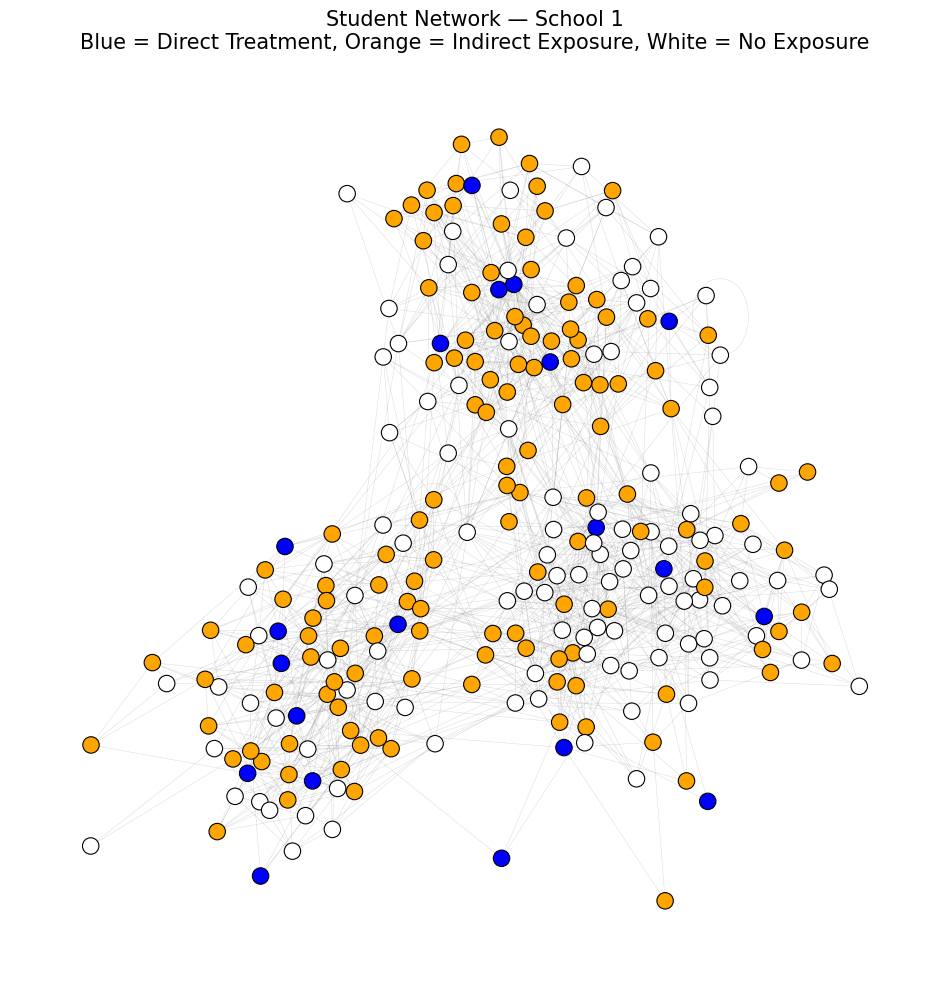

In [13]:
G_school_lcc = plot_school_exposure_network(df_sub, adjacency_directed, school_id=1)

## Part 3: Calculating Causal Estimands

### Step 1: Approximate Exposure Probabilities πᵢ(dₖ)

Aronow & Samii define a generalized probability of exposure $\pi_i$ for every student $i: πᵢ(d) = Pr(Z = z)$. A unit $i$'s generalized probability of exposure $\pi_i$  tells us the probability of $i$ being subject to each of the possible exposures in $\{d_1, \ldots, d_K\}$:

$$\pi_i(d_k)
= \sum_{z \in \Omega} I\!\left(f(z, \theta_i) = d_k\right)\Pr(Z = z)
= \sum_{z \in \Omega} p_z \, I\!\left(f(z, \theta_i) = d_k\right).$$

We calculate this by using the randomization design from the experiment:

- School‐level treatment is fixed (SCHTREAT from data - half of schools were assigned treatment and half control)
- Seed-eligibility (ie. whether a student is eligible to receive treatment) is also fixed based on an algorithm that selected a group of students selected to potentially participate in the Roots (shown by TREAT ∈ {1,2} in the dataset). Designed to represent roughly 15% of the school population, blocked by gender and grade.
- Within schools, seed-eligible students are randomized with P 0.5 into treated or control
- Seed‐ineligible students are always control
- Students in control schools are always control

Therefore, to calculate the exposure probabilities, we randomise $Z$ only among the seed-eligible students in treated schools. 

We approximate these exposure probabilities using a Monte Carlo simulation, repeatedly drawing treatment assignments from the experiment’s actual randomization design and recording how often each unit falls into each exposure condition. This follows Aronow and Samii’s recommendation, since the full assignment space $\Omega$ is often too large to construct explicitly, making exact computation of exposure probabilities infeasible.

In [14]:
def simulate_exposure_probabilities(
    df_sub,
    adj_directed,
    R=5000,
    levels=None,
    seed=123
):
    """
    Estimate exposure probabilities π_i(d) via simulation under ROOTS design.
    """
    np.random.seed(seed)

    # ---------------------------
    # 1. BASIC INDEX SETUP
    # ---------------------------
    uids = sorted(df_sub["UID"].unique())
    N = len(uids)
    uid_to_idx = {u: i for i, u in enumerate(uids)}

    # ---------------------------
    # 2. UNDIRECTED ADJACENCY
    # ---------------------------
    adj_undir = [[] for _ in range(N)]

    for ego_uid, neighs in adj_directed.items():
        if ego_uid not in uid_to_idx:
            continue
        i = uid_to_idx[ego_uid]

        for friend_uid in neighs:
            if friend_uid not in uid_to_idx:
                continue
            j = uid_to_idx[friend_uid]

            adj_undir[i].append(j)
            adj_undir[j].append(i)

    # ---------------------------
    # 3. SCHOOL INDEXING
    # ---------------------------
    school_ids = np.sort(df_sub["SCHID"].unique())
    school_to_idx = {s: j for j, s in enumerate(school_ids)}

    school_of = np.array([
        school_to_idx[df_sub.loc[df_sub["UID"] == u, "SCHID"].iloc[0]]
        for u in uids
    ])

    J = len(school_ids)

    # ---------------------------
    # 4. SCHOOL TREATMENT (FIXED)
    # ---------------------------
    df_sub["SCHTREAT_num"] = (
        df_sub["SCHTREAT"].astype(str).str.extract(r"(\d)").astype(float).fillna(0).astype(int)
    )

    S_school_fixed = (
        df_sub.groupby("SCHID")["SCHTREAT_num"]
        .first()
        .loc[school_ids]
        .values
    )

    # ---------------------------
    # 5. SEED ELIGIBILITY
    # ---------------------------
    df_sub["TREAT_num"] = (
        df_sub["TREAT"].astype(str).str.extract(r"(\d+)").astype(float).fillna(0).astype(int)
    )

    elig = df_sub.set_index("UID").loc[uids, "TREAT_num"].isin([1, 2]).values

    # ---------------------------
    # 6. EXPOSURE LEVELS
    # ---------------------------
    if levels is None:
        levels = ["d000", "d001", "d011", "d101", "d111"]

    level_to_idx = {d: k for k, d in enumerate(levels)}

    # Exposure mapping
    def exposure_5cat(Z):
        D = np.empty(N, dtype=object)
        S = S_school_fixed[school_of]

        neigh_tr = np.array([
            Z[adj_undir[i]].sum() if adj_undir[i] else 0
            for i in range(N)
        ])

        for i in range(N):
            si, zi, nt = S[i], Z[i], neigh_tr[i]
            if si == 0:
                D[i] = "d000"
            elif zi == 1 and nt > 0:
                D[i] = "d111"
            elif zi == 1 and nt == 0:
                D[i] = "d101"
            elif zi == 0 and nt > 0:
                D[i] = "d011"
            else:
                D[i] = "d001"
        return D

    # ---------------------------
    # 7. RANDOMIZATION
    # ---------------------------
    def randomize_once():
        Z = np.zeros(N, dtype=int)
        for j in range(J):
            idxs = np.where(school_of == j)[0]
            if S_school_fixed[j] == 1:
                elig_idxs = idxs[elig[idxs]]
                m = len(elig_idxs)
                k = m // 2
                if k > 0:
                    chosen = np.random.choice(elig_idxs, k, replace=False)
                    Z[chosen] = 1
        return Z

    # ---------------------------
    # 8. SIMULATION
    # ---------------------------
    D_sims_idx = np.zeros((R, N), dtype=int)

    for r in range(R):
        Z = randomize_once()
        D = exposure_5cat(Z)
        D_sims_idx[r] = [level_to_idx[d] for d in D]

    counts = np.zeros((N, len(levels)), dtype=int)
    for r in range(R):
        counts[np.arange(N), D_sims_idx[r]] += 1

    pi_df = pd.DataFrame(counts / R, index=uids, columns=levels)

    # ---------------------------
    # RETURN
    # ---------------------------
    objects = dict(
        uids=uids,
        uid_to_idx=uid_to_idx,
        adj_undir=adj_undir,
        school_of=school_of,
        S_school_fixed=S_school_fixed,
        elig=elig,
        levels=levels
    )

    return pi_df, objects, D_sims_idx, exposure_5cat


Here we run a simulation with R=5000 and check the first few results:

In [17]:
pi_df, objects, D_sims_idx, exposure_5cat= simulate_exposure_probabilities(
    df_sub,
    adjacency_directed,
    R=5000
)

print(pi_df.head(10))


        d000    d001    d011    d101    d111
100001   0.0  0.2366  0.7634  0.0000  0.0000
100002   0.0  0.2366  0.2648  0.2544  0.2442
100003   0.0  0.2486  0.7514  0.0000  0.0000
100004   0.0  0.1168  0.8832  0.0000  0.0000
100005   0.0  0.5014  0.4986  0.0000  0.0000
100006   0.0  0.1134  0.8866  0.0000  0.0000
100007   0.0  0.5014  0.4986  0.0000  0.0000
100008   0.0  0.1182  0.8818  0.0000  0.0000
100009   0.0  0.5014  0.4986  0.0000  0.0000
100010   0.0  0.4960  0.5040  0.0000  0.0000


Now, we create a comparison table to see how these estimates appear for four students in different conditions:

In [18]:
# Display the results to compare for selected students

def compare_students(
        uids_to_check,
        df_sub,
        adj_directed,
        pi_df,
        D_sims_idx,
        R,
        objects
):
    """
    Build a comparison table for selected students, showing:
      - school treatment
      - student eligibility
      - peer degree
      - empirical P(Z_i=1)
      - exposure probabilities π_i(d)

    Parameters
    ----------
    uids_to_check : list
        List of UIDs to examine.
    df_sub : DataFrame
        Student-level dataset.
    adj_directed : dict
        Directed adjacency list.
    pi_df : DataFrame
        Exposure probabilities π_i(d) from simulation.
    D_sims_idx : np.array
        R × N exposure category matrix (stored in simulate function).
    R : int
        Number of simulation replications.
    objects : dict
        Supporting objects returned by simulate_exposure_probabilities().
    
    Returns
    -------
    comparison_df : DataFrame
        Table comparing selected students.
    """

    # Extract elements from objects dict
    uids          = objects["uids"]
    uid_to_idx    = objects["uid_to_idx"]
    adj_undir     = objects["adj_undir"]
    school_of     = objects["school_of"]
    S_school_fixed = objects["S_school_fixed"]
    levels        = objects["levels"]

    # Rebuild level index mapping
    level_to_idx = {d: k for k, d in enumerate(levels)}

    # Validate the input UIDs
    for u in uids_to_check:
        if u not in pi_df.index:
            raise ValueError(f"UID {u} not found in pi_df.")

    rows = []

    # Map UID → school index
    school_ids = sorted(df_sub["SCHID"].unique())
    school_to_idx = {s: j for j, s in enumerate(school_ids)}

    # Seed eligibility
    elig = df_sub.set_index("UID").loc[uids, "TREAT_num"].isin([1, 2]).values

    # Build rows
    for uid in uids_to_check:
        i = uid_to_idx[uid]
        sch = df_sub.loc[df_sub["UID"] == uid, "SCHID"].iloc[0]
        school_idx = school_to_idx[sch]

        school_treat = S_school_fixed[school_idx]
        eligible = bool(elig[i])

        # Raw treatment label
        raw_treat_label = df_sub.loc[df_sub["UID"] == uid, "TREAT"].iloc[0]

        # P(Z_i = 1) from simulation
        P_Z1 = (
            (D_sims_idx[:, i] == level_to_idx["d101"]).sum()
            + (D_sims_idx[:, i] == level_to_idx["d111"]).sum()
        ) / R

        # Degree using UNDIRECTED adjacency built earlier
        neighbors = set(adj_directed.get(uid, [])) | {uids[j] for j in adj_undir[i]}
        degree = len(neighbors)

        pi_vals = pi_df.loc[uid]

        rows.append({
            "UID": uid,
            "SCHID": sch,
            "School_Treated": school_treat,
            "Treatment": raw_treat_label,
            "Eligible": eligible,
            "Number of peer connections": degree,
            "Empirical P(Z_i=1)": round(P_Z1, 3),
            "π(d000)": round(pi_vals["d000"], 3),
            "π(d001)": round(pi_vals["d001"], 3),
            "π(d011)": round(pi_vals["d011"], 3),
            "π(d101)": round(pi_vals["d101"], 3),
            "π(d111)": round(pi_vals["d111"], 3),
        })

    comparison_df = pd.DataFrame(rows)
    return comparison_df



In [20]:
#Select students from the dataset
uids= [1100009, 600305, 100002, 1200194]

comparison_df = compare_students(
    uids_to_check=uids,
    df_sub=df_sub,
    adj_directed=adjacency_directed,
    pi_df=pi_df,
    D_sims_idx=D_sims_idx,
    R=500,
    objects=objects
)

display(comparison_df)

,UID,SCHID,School_Treated,Treatment,Eligible,Number of peer connections,Empirical P(Z_i=1),π(d000),π(d001),π(d011),π(d101),π(d111)
0,1100009,11,0,(0) Not treatment or control,False,8,0.000,1.0,0.000,0.000,0.000,0.000
1,600305,6,1,(1) Treatment,True,16,4.972,0.0,0.122,0.381,0.135,0.362
2,100002,1,1,(2) Control,True,14,4.986,0.0,0.237,0.265,0.254,0.244
3,1200194,12,0,(1) Treatment,True,11,0.000,1.0,0.000,0.000,0.000,0.000


### Step 2: Compare different Estimators

The paper implements Horvitz-Thompson (HT), Hajek, and weighted least squares (WLS) estimates of the effects of different exposure conditions relative to the no exposure condition.

We compute the average outcome under different exposures using the following methods:

1. Horvitz–Thompson (HT) estimator: It uses inverse probability weighting based on the exposure probabilities to obtain unbiased estimates of the average potential outcome under each exposure condition. If a unit is rarely in a particular exposure, their outcome is given more weight.

2. Hajek estimator: Similar to HT, but it normalizes the HT weights such that the sum is equal to 1 within each exposure group. The method generally gives a lower variance compared to HT, and is less sensitive to rare exposures.

3. Weighted Least Squares (WLS): WLS regresses outcome on exposure indicators but weighs each unit by the inverse of its exposure probability.  

As per the paper, only students selected as “seed-eligible” have a non-zero possibility of being in all four exposure conditions. Thus, we limit the present analysis to the set of students who are labelled as seed-eligible. 

We have kept the outcome variable as whether students are wearing a Roots wristband after the intervention takes place (binary). This was one of the variables used to measure behavioural change due to the intervention. 

In [21]:
from dataclasses import dataclass
from typing import List, Dict
import numpy as np
import pandas as pd

@dataclass
class ExposureEstimator:
    """
    Exposure Estimator performs several estimation methods for causal inference under interference.

    Parameters:
    Y: Outcome vector for each unit (UIDs, observed outcomes-WRISTW2)
    I_obs: Indicator matrix for exposure categories (UIDs, I_obs[i, d] = 1 if unit i is in exposure condition d)
    pi_df: Simulation probabilities
    levels: Ordered list of exposure categories ("d000", "d001", "d011", "d101", "d111")
    baseline: The exposure category against which causal effects are computed 
    """
    Y: pd.Series ()
    I_obs: pd.DataFrame
    pi_df: pd.DataFrame
    levels: List[str]
    baseline: str = "d000"

    def _check_align(self):
        assert (self.Y.index == self.I_obs.index).all(), "Y and I_obs must have same index"
        assert (self.Y.index == self.pi_df.index).all(), "Y and pi_df must have same index"

    # -------------------------------------------------------
    # Horvitz–Thompson estimator μ_HT(d)
    # -------------------------------------------------------
    def mu_ht(self) -> Dict[str, float]:
        self._check_align()
        out = {}
        for d in self.levels:
            mask = self.pi_df[d] > 0
            numer = self.I_obs.loc[mask, d] * (self.Y.loc[mask] / self.pi_df.loc[mask, d])
            out[d] = numer.mean()
        return out

    # -------------------------------------------------------
    # Hájek estimator μ_H(d)
    # -------------------------------------------------------
    def mu_hajek(self) -> Dict[str, float]:
        self._check_align()
        out = {}
        for d in self.levels:
            mask = self.pi_df[d] > 0
            w = self.I_obs.loc[mask, d] / self.pi_df.loc[mask, d]
            numer = (w * self.Y.loc[mask]).sum()
            denom = w.sum()
            out[d] = numer / denom if denom > 0 else np.nan
        return out

    # -------------------------------------------------------
    # WLS estimator
    # -------------------------------------------------------
    def mu_wls(self) -> Dict[str, float]:
        import statsmodels.api as sm
        self._check_align()

        X = self.I_obs[self.levels].astype(float)
        W = 1 / self.pi_df[self.levels].replace(0, np.nan)
        weights = W.sum(axis=1)

        model = sm.WLS(self.Y, X, weights=weights).fit()
        return dict(model.params)

    # -------------------------------------------------------
    # Causal effects
    # -------------------------------------------------------
    def causal_effects(self, mu_dict: Dict[str, float]) -> Dict[str, float]:
        tau = {}
        for d in self.levels:
            if d != self.baseline:
                tau[d] = mu_dict[d] - mu_dict[self.baseline]
        return tau

    # -------------------------------------------------------
    # Summary Table
    # -------------------------------------------------------
    def summarise(self):
        mu_ht = self.mu_ht()
        mu_hajek = self.mu_hajek()
        mu_wls = self.mu_wls()

        mu_table = pd.DataFrame({
            "μ_HT": mu_ht,
            "μ_Hajek": mu_hajek,
            "μ_WLS": mu_wls
        })

        tau_ht = self.causal_effects(mu_ht)
        tau_haj = self.causal_effects(mu_hajek)
        tau_wls = self.causal_effects(mu_wls)

        effects_rows = []
        for d in self.levels:
            if d != self.baseline:
                effects_rows.append({
                    "contrast": f"{d} vs {self.baseline}",
                    "τ_HT": tau_ht[d],
                    "τ_Hajek": tau_haj[d],
                    "τ_WLS": tau_wls[d]
                })

        effects_df = pd.DataFrame(effects_rows)
        return mu_table, effects_df


In [22]:
# now compute observed Z
Z_obs = (
    df_sub.set_index("UID")
    .loc[objects["uids"], "TREAT_num"]
    .astype(int)
    .values
)

# compute observed exposure category
D_obs = exposure_5cat(Z_obs)
D_obs_by_uid = pd.Series(D_obs, index=objects["uids"])

In [23]:
I_obs = pd.get_dummies(D_obs_by_uid)[objects["levels"]]
print(f"Observed count for d011 in full data: {I_obs['d011'].sum()}")

Observed count for d011 in full data: 1248


In [24]:
levels = objects["levels"]
uids = objects["uids"]

df_sub["WRISTW2_num"] = (
    df_sub["WRISTW2"].astype(str).str.extract(r"(\d)").astype(float)
)

Y = df_sub.set_index("UID").loc[uids, "WRISTW2_num"]
print(f"Size of Y after creation: {len(Y)}") 
print(f"Number of UIDs in simulation: {len(objects['uids'])}")

Size of Y after creation: 5989
Number of UIDs in simulation: 5989


In [26]:
mask =Y.notna().values

Y_sub = Y.loc[mask]
I_sub = I_obs.loc[mask]
pi_sub = pi_df.loc[mask]

N_sub=len(Y_sub)
print(f"Final sample size for estimation (N_sub): {N_sub}")

N_total = len(Y)
N_missing_Y = Y.isna().sum()
print(f"Total units in the simulation (N): {N_total}")
print(f"Units with missing outcome (Y.isna()): {N_missing_Y}")

N_eligible = objects["elig"].sum()
print(f"Units marked as eligible (elig=True): {N_eligible}")

est = ExposureEstimator(
    Y=Y_sub,
    I_obs=I_sub,
    pi_df=pi_sub,
    levels=objects["levels"],
    baseline="d000"
)

mu_table, tau_table = est.summarise()

print("=== Exposure-Specific Means (μ) ===")
display(mu_table)

print("\n=== Causal Effects Relative to Baseline (τ) ===")
display(tau_table)


Final sample size for estimation (N_sub): 4901
Total units in the simulation (N): 5989
Units with missing outcome (Y.isna()): 1088
Units marked as eligible (elig=True): 824


ModuleNotFoundError: No module named 'statsmodels'

## Part 4: Playground

Now, we would like you to experiment with different exposure mappings and check whether it significantly influences the results observed earlier for both expected outcomes and causal effects. For this section, we will switch from discrete mapping seen earlier to proportion mapping.

In [91]:
# PROPORTION MAPPING FUNCTION #

# NOTE: This function replaces the "exposure_map_func" argument in run_scenario.
# It uses the original 5-category codes (d000, d001, d011, d101, d111) 
# but changes the definition of "Indirect Exposure" (d011/d111).

def map_proportion_threshold(Z, S_fixed_local, school_of_local, adj_undir_local, N_local):
    """
    Defines exposure based on the PROPORTION of treated peers, 
    using a TWEAKABLE threshold.
    """
    # 🚨 TWEAKABLE PLACEHOLDER 🚨
    # Change this value to see how the results change.
    PROPORTION_THRESHOLD = 0.25 
    # -----------------------------
    
    D = np.empty(N_local, dtype=object)
    S = S_fixed_local[school_of_local] 
    
    # Calculate treated neighbors count (nt) and total neighbors count (N_i)
    nt_array = np.array([
        Z[adj_undir_local[i]].sum() if adj_undir_local[i] else 0
        for i in range(N_local)
    ])
    Ni_array = np.array([
        len(adj_undir_local[i]) for i in range(N_local)
    ])

    # Calculate proportion of treated neighbors (Pi)
    # Use np.divide and fill NaNs (from 0/0 division) with 0.
    Pi_array = np.nan_to_num(np.divide(nt_array, Ni_array, where=Ni_array!=0))

    for i in range(N_local):
        si, zi = S[i], Z[i]
        Pi = Pi_array[i]

        # Rule 1: Control School (S=0) - No Change
        if si == 0:
            D[i] = "d000"
            
        # Rule 2 & 3: Direct Treatment (Z=1)
        elif zi == 1:
            if Pi > PROPORTION_THRESHOLD: # Direct + STRONG Indirect
                D[i] = "d111"
            else: # Direct + WEAK/No Indirect
                D[i] = "d101"

        # Rule 4 & 5: No Direct Treatment (Z=0)
        elif zi == 0:
            if Pi > PROPORTION_THRESHOLD: # Indirect Only (if threshold met)
                D[i] = "d011"
            else: # Treated School, but no strong indirect exposure
                D[i] = "d001" 
            
    return D

In [93]:
def simulate_exposure_probabilities(
    df_sub,
    adj_directed,
    R=5000,
    levels=None,
    seed=123,
    custom_map_func=None # <-- NEW ARGUMENT
):
    """
    Estimate exposure probabilities π_i(d) via simulation under ROOTS design.
    """
    np.random.seed(seed)

    # ---------------------------
    # 1-5. DATA PREP (Indices, Adjacency, School/Eligibility)
    # (Existing code for uids, N, adj_undir, school_of, S_school_fixed, elig)
    # ---------------------------
    uids = sorted(df_sub["UID"].unique())
    N = len(uids)
    uid_to_idx = {u: i for i, u in enumerate(uids)}

    adj_undir = [[] for _ in range(N)]
    for ego_uid, neighs in adj_directed.items():
        if ego_uid not in uid_to_idx: continue
        i = uid_to_idx[ego_uid]
        for friend_uid in neighs:
            if friend_uid not in uid_to_idx: continue
            j = uid_to_idx[friend_uid]
            adj_undir[i].append(j)
            adj_undir[j].append(i)

    school_ids = np.sort(df_sub["SCHID"].unique())
    school_to_idx = {s: j for j, s in enumerate(school_ids)}
    school_of = np.array([
        school_to_idx[df_sub.loc[df_sub["UID"] == u, "SCHID"].iloc[0]]
        for u in uids
    ])
    J = len(school_ids)
    
    df_sub["SCHTREAT_num"] = (
        df_sub["SCHTREAT"].astype(str).str.extract(r"(\d)").astype(float).fillna(0).astype(int)
    )
    S_school_fixed = (
        df_sub.groupby("SCHID")["SCHTREAT_num"]
        .first()
        .loc[school_ids]
        .values
    )
    
    df_sub["TREAT_num"] = (
        df_sub["TREAT"].astype(str).str.extract(r"(\d+)").astype(float).fillna(0).astype(int)
    )
    elig = df_sub.set_index("UID").loc[uids, "TREAT_num"].isin([1, 2]).values


    # ---------------------------
    # 6. EXPOSURE LEVELS & MAPPING (Standard 5-Cat)
    # ---------------------------
    if levels is None:
        levels = ["d000", "d001", "d011", "d101", "d111"]

    level_to_idx = {d: k for k, d in enumerate(levels)}

    # Exposure mapping - UPDATED SIGNATURE to pass context variables explicitly
    def exposure_5cat(Z, S_fixed_local, school_of_local, adj_undir_local, N_local):
        D = np.empty(N_local, dtype=object)
        S = S_fixed_local[school_of_local]

        neigh_tr = np.array([
            Z[adj_undir_local[i]].sum() if adj_undir_local[i] else 0
            for i in range(N_local)
        ])

        for i in range(N_local):
            si, zi, nt = S[i], Z[i], neigh_tr[i]
            if si == 0:
                D[i] = "d000"
            elif zi == 1 and nt > 0:
                D[i] = "d111"
            elif zi == 1 and nt == 0:
                D[i] = "d101"
            elif zi == 0 and nt > 0:
                D[i] = "d011"
            else:
                D[i] = "d001"
        return D

    # ---------------------------
    # 7. RANDOMIZATION
    # ---------------------------
    def randomize_once():
        Z = np.zeros(N, dtype=int)
        for j in range(J):
            idxs = np.where(school_of == j)[0]
            if S_school_fixed[j] == 1:
                elig_idxs = idxs[elig[idxs]]
                m = len(elig_idxs)
                k = m // 2
                if k > 0:
                    chosen = np.random.choice(elig_idxs, k, replace=False)
                    Z[chosen] = 1
        return Z

    # ---------------------------
    # 8. SIMULATION
    # ---------------------------
    
    # Use the custom function if provided, otherwise use the standard 5-category function
    if custom_map_func is not None:
        simulation_exposure_func = custom_map_func
    else:
        simulation_exposure_func = exposure_5cat 

    D_sims_idx = np.zeros((R, N), dtype=int)

    for r in range(R):
        Z = randomize_once()
        
        # Call the selected function, passing all context variables required
        D = simulation_exposure_func(Z, S_school_fixed, school_of, adj_undir, N) 
        
        D_sims_idx[r] = [level_to_idx[d] for d in D]

    counts = np.zeros((N, len(levels)), dtype=int)
    for r in range(R):
        counts[np.arange(N), D_sims_idx[r]] += 1

    pi_df = pd.DataFrame(counts / R, index=uids, columns=levels)

    # ---------------------------
    # RETURN
    # ---------------------------
    objects = dict(
        uids=uids,
        uid_to_idx=uid_to_idx,
        adj_undir=adj_undir,
        school_of=school_of,
        S_school_fixed=S_school_fixed,
        elig=elig,
        levels=levels,
        N=N # Include N for convenience
    )

    # Return pi_df, objects, D_sims_idx, and the standard exposure function for I_obs calculation
    return pi_df, objects, D_sims_idx, exposure_5cat

In [ ]:
# GENERATE ALIGNED PI_DF AND RUN ESTIMATOR

# 1. Generate ALIGNED pi_df (Probability Weights)
# Pass the custom function to simulate_exposure_probabilities
print("--- Generating ALIGNED Pi_df (Probabilities) ---")
pi_df_aligned, objects, D_sims_idx, exposure_5cat_base = simulate_exposure_probabilities(
    df_sub, adj_directed, R=5000, custom_map_func=map_proportion_threshold
)

# Extract context variables for I_obs calculation
uids = objects["uids"]
N = objects["N"]
S_school_fixed = objects["S_school_fixed"]
school_of = objects["school_of"]
adj_undir = objects["adj_undir"]
levels = objects["levels"]

# 2. Prepare Observed Inputs (Y and Z_obs)
df_sub["WRISTW2_num"] = df_sub["WRISTW2"].astype(str).str.extract(r"(\d)").astype(float)
Y = df_sub.set_index("UID").loc[uids, "WRISTW2_num"]
Z_obs = (df_sub.set_index("UID").loc[uids, "TREAT_num"].apply(lambda x: 1 if x == 1 else 0).values)

# 3. Compute ALIGNED Observed Exposure (I_obs)
D_obs_aligned = map_proportion_threshold(Z_obs, S_school_fixed, school_of, adj_undir, N)
D_obs_by_uid_aligned = pd.Series(D_obs_aligned, index=uids)
I_obs_aligned = pd.get_dummies(D_obs_by_uid_aligned)[levels]

# 4. Define Final Analytical Sample
mask = Y.notna().values
Y_sub = Y.loc[mask]
pi_sub_aligned = pi_df_aligned.loc[mask]
I_sub_aligned = I_obs_aligned.loc[mask]

print(f"Analytical Sample Size (Y.notna()): {len(Y_sub)}")

# 5. Run Exposure Estimator
print("\n--- Running ExposureEstimator with P > 25% Threshold ---")
est_aligned = ExposureEstimator(
    Y=Y_sub,
    I_obs=I_sub_aligned,
    pi_df=pi_sub_aligned,
    levels=levels,
    baseline="d000"
)

mu_table_aligned, tau_table_aligned = est_aligned.summarise()

print("\n=== Causal Effects Results: P > 25% Proportion Threshold ===")

print("\nEstimated Means (μ):")
display(mu_table_aligned.round(4))

print("\nCausal Effects (τ vs d000):")
display(tau_table_aligned.round(4))

--- Generating ALIGNED Pi_df (Probabilities) ---
